# Feature selection

Autores: Pablo Hernández Cámara (pablo.hernandez-camara@uv.es) y Pedro Ramón Ventura Gómez (pventura@march-am.com)



En este notebook vamos a ver otros métodos de feature extraction distintos a PCA.

## Other linear methods

Igual que PCA, estos métodos son lineales, es decir, las nuevas cracaterísticas extraidas son combinaciones lineales de las existentes.

En particular vamos a ver otros métodos lineales que buscan otros objetivos distintos a encontrar las direcciones de máxima varianza, como ICA (Indepenendent Component Analisis), que busca las direcciones independientes; o LDA (Linear Discriminant Analysis), un método supervisado que buscas las direcciones que proporcionan una mayor separabilidad de las clases.

In [ ]:
from sklearn import datasets
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
import pandas as pd
import numpy as np

### ICA

Vamos a empezar por el ICA (Independent Component Analysis). Normalmente se utiliza el algoritmo de FastICA, desarrollado por Hyvärinen en 1999. Es un algoritmo iterativo que encuentra componentes independientes maximizando la negentropía entre las variables. Se basa en aplicar rotaciones y escalados a los datos de forma iterativa.


En primer lugar, generamos unos datos.

In [ ]:
rng = np.random.RandomState(42)
S = rng.standard_t(1.5, size=(20000, 2))
S[:, 0] *= 2.0
A = np.array([[1, 1], [0, 2]])
X = np.dot(S, A.T)
print(X.shape)

(20000, 2)


**Ejercicio: Representa los datos.**

**Ejercicio: Sin hacer nada aun. ¿Que direcciones crees que va a encontrar PCA? ¿E ICA?**

Vamos a aplicar primero PCA y luego ICA y comparamos el resultado.

**Ejercicio: Aplica PCA y transforma los datos.**

**Ejercicio: Haz lo mismo con ICA.**

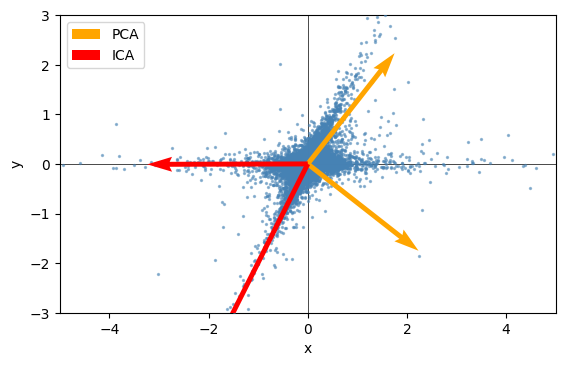

In [ ]:
def plot_samples(S, axis_list=None):
    plt.scatter(
        S[:, 0], S[:, 1], s=2, marker="o", zorder=10, color="steelblue", alpha=0.5
    )
    if axis_list is not None:
        for axis, color, label in axis_list:
            x_axis, y_axis = axis / axis.std()
            plt.quiver(
                (0, 0),
                (0, 0),
                x_axis,
                y_axis,
                zorder=11,
                width=0.01,
                scale=6,
                color=color,
                label=label,
            )

    plt.hlines(0, -5, 5, color="black", linewidth=0.5)
    plt.vlines(0, -3, 3, color="black", linewidth=0.5)
    plt.xlim(-5, 5)
    plt.ylim(-3, 3)
    plt.gca().set_aspect("equal")
    plt.xlabel("x")
    plt.ylabel("y")


axis_list = [(pca.components_.T, "orange", "PCA"), (ica.mixing_, "red", "ICA")]
plot_samples(X / np.std(X), axis_list=axis_list)
legend = plt.legend(loc="upper left")
legend.set_zorder(100)
plt.show()

**Ejercicio: Representa los datos originales, los transformados por PCA y los transformados por ICA.**

### LDA

El Linear Discriminant Analsysis (LDA) es un método supervisado, es decir, utiliza la información de las etiquetas/variable a predecir. Su objetivo, como hemos visto, es encontrar las direcciones que proporcionan una mayor separabilidad de las clases a predecir.

In [ ]:
from sklearn import datasets
import math
import pandas as pd

iris = datasets.load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Vamos a hacer ahora el LDA para reducir a dos dimensiones.

**Ejercicio: Usa ``LinearDiscriminantAnalysis`` de sklearn y reduce a dos dimensiones. Fijate que como es un método supervisado tendrás que pasarle no solo X si no tambien y.**

**Ejercicio: Haz ahora el histograma de la primera dimension encontrada por el LDA.**

**Ejercicio: Representa el scatter plot de los datos en el espacio del LDA. Hazlo también en PCA para ver las diferencias.**

Vamos a probar con otros datos!

In [ ]:
import scipy.io.matlab as matlab
mat = matlab.loadmat("extrac_train.mat", squeeze_me=True)

X = mat["x1"]
y = mat["clab1"]
del mat

**Ejercicio: ¿Cuantos datos tenemos? ¿Cuantas variables? ¿Es un problema de clasificacion o regresion?**

En este caso tenemos 450 datos con 200 variables y es un problema de clasificación con 3 clases.

**Ejercicio: Aplica tanto PCA como LDA para bajar de 200 a 2 dimensiones. Representa los datos transformados a este espacio. ¿Con que método obtienes mejores resultados si luego quisieras entrenar un clasificador lineal?**

### MDS

El método Multi-Dimensional Scaling se basa en calcular las distancias entre todos los pares de muestras y transformar a un espacio donde estas distancias se mantengan lo más parecidas posibles.

In [ ]:
# Generate the data
EPSILON = np.finfo(np.float32).eps
n_samples = 20
rng = np.random.RandomState(seed=3)
X_true = rng.randint(0, 20, 2 * n_samples).astype(float)
X_true = X_true.reshape((n_samples, 2))
X_true -= X_true.mean()

print(X_true.shape)

(20, 2)


**Ejercicio: Representa los datos.**

**Ejercicio: Usando ``from sklearn.metrics import euclidean_distances`` calcula las distancias entre todos los puntos. ¿Que dimensiones va a tener? Representa estas distancias. ¿Cuales son los puntos más alejados?**

Vamos a aplicar ahora MDS.

In [ ]:
noise = rng.rand(n_samples, n_samples)
noise = noise + noise.T
np.fill_diagonal(noise, 0)
distances += noise

In [ ]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, metric=True, dissimilarity='precomputed')
X_mds = mds.fit_transform(distances)

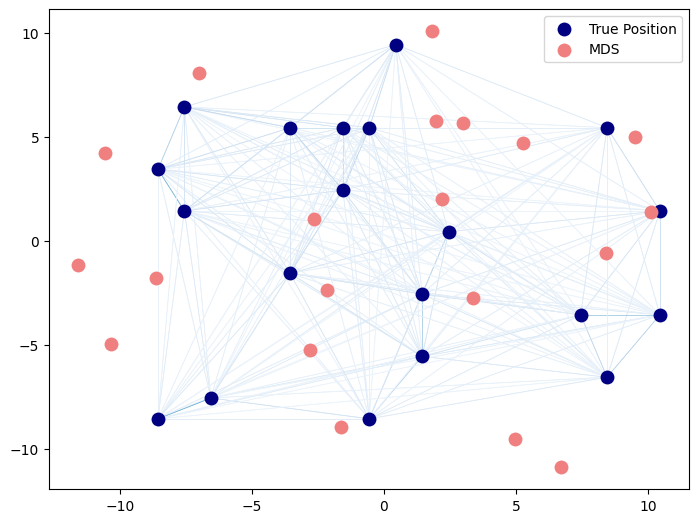

In [ ]:
from matplotlib.collections import LineCollection

fig = plt.figure(1)
ax = plt.axes([0.0, 0.0, 1.0, 1.0])
plt.scatter(X_true[:, 0], X_true[:, 1], color="navy", s=100, lw=0, label="True Position")
plt.scatter(X_mds[:, 0], X_mds[:, 1], color="lightcoral", s=100, lw=0, label="MDS")
plt.legend(scatterpoints=1, loc="best", shadow=False)
start_idx, end_idx = X_mds.nonzero()
segments = [[X_true[i, :], X_true[j, :]] for i in range(len(X_true)) for j in range(len(X_true))]
edges = distances.max() / (distances + EPSILON) * 100
np.fill_diagonal(edges, 0)
edges = np.abs(edges)
lc = LineCollection(segments, zorder=0, cmap=plt.cm.Blues, norm=plt.Normalize(0, edges.max()))
lc.set_array(edges.flatten())
lc.set_linewidths(np.full(len(segments), 0.5))
ax.add_collection(lc)
plt.show()

## Non-linear methods

Vamos a ver ahora distintos métodos no lineales de los que hemos visto en la parte de teoria. Recordad que cada método optimiza/busca cosas distintas y por lo tanto cual debemos usar dependerá de lo que queramos hacer y de como sean nuestros datos. No hay una regla fija sobre cual usar.

### ISOMAP

Isomap se basaba en calcular las distancias entre puntos, parecido al MDS, pero midiendo las distancias a lo largo del manifold. Esta simple diferencia le permite mantener mucho mejor la estructura global de los datos y ser capaz de procesar estructuras no lineales.

Importante: Como los puntos lejanos tienen distancias mayores, estas influyen más y por lo tanto el método optimiza más la estructura global (distancias largas) que las estructuras locales.

In [ ]:
from sklearn.datasets import make_s_curve

n_samples = 1500
S_points, S_color = make_s_curve(n_samples, random_state=0)
print(S_points.shape)

(1500, 3)


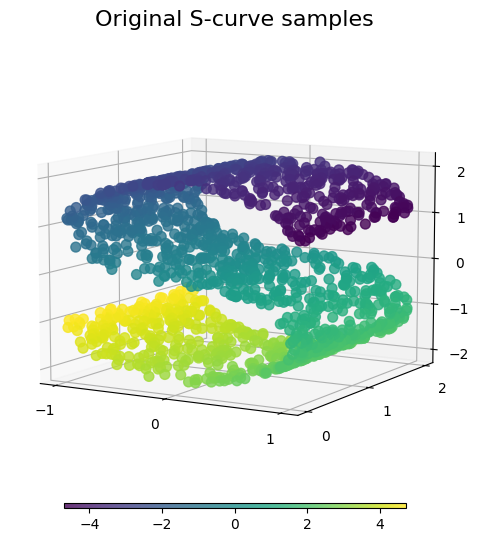

In [ ]:
import mpl_toolkits.mplot3d  # noqa: F401
from matplotlib import ticker

def plot_3d(points, points_color, title):
    x, y, z = points.T

    fig, ax = plt.subplots(
        figsize=(6, 6),
        facecolor="white",
        tight_layout=True,
        subplot_kw={"projection": "3d"},
    )
    fig.suptitle(title, size=16)
    col = ax.scatter(x, y, z, c=points_color, s=50, alpha=0.8)
    ax.view_init(azim=-60, elev=9)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.zaxis.set_major_locator(ticker.MultipleLocator(1))

    fig.colorbar(col, ax=ax, orientation="horizontal", shrink=0.6, aspect=60, pad=0.01)
    plt.show()


def plot_2d(points, points_color, title):
    fig, ax = plt.subplots(figsize=(3, 3), facecolor="white", constrained_layout=True)
    fig.suptitle(title, size=16)
    add_2d_scatter(ax, points, points_color)
    plt.show()


def add_2d_scatter(ax, points, points_color, title=None):
    x, y = points.T
    ax.scatter(x, y, c=points_color, s=50, alpha=0.8)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())


plot_3d(S_points, S_color, "Original S-curve samples")

**Ejercicio: Usa ``Isomap(n_neighbors=n_neighbors, n_components=n_components, p=1)`` y reduce a dos dimensiones. Usa  n_neighbors = 12.**

Vamos a ver como influye el número de vecinos, recordad que es el número de puntos que se coje alrededor de cada dato para construir el grafo con el que calcular las distancias a lo largo del manifold.

**Ejercicio: Entrena y representa el resultado de aplicar Isomap con n_neighbors = {3,6,12,24}.**

### t-SNE

A diferencia de Isomap que calcula las distancias entre todos los pares de puntos a lo largo del manifold, t-SNE se basa en distribuciones de probabilidad.

Mas detalladamente, t-SNE ajusta una gaussiana para cada punto asignando probabilidades segun la distancia a la que esten los puntos: Dos puntos cercanos "tienen mas probabilidad de ser vecinos".

El objetivo de t-SNE es pues encontrar un espacio de dimensión inferior donde esta distribución de probabilidad se mantenga lo más parecida posible a la original usando la divergencia Kullback-Leibler entre las distribuciones en el espacio original y el transformado.

**Ejercicio: Usa ahora ``TSNE(n_components=n_components, perplexity=perplexity, init="random", max_iter=250, random_state=0)`` también de sklearn con perplexity = 30.**

Vamos a ver también como afecta el "perplexity", número de puntos en los que que cada dato se fija para ajustar sus distribuciones de probabilidad.

**Ejercicio: Ejecuta t-SNE con distintos valores de perplexity, por ejemplo {5,10,20,30,50,100}. ¿Como cambian los resultados?**

### UMAP

UMAP combina lo mejor de Isomap y t-SNE, logrando mantener la estructura global y la local, además de ser mucho más rápido.

Para ello, UMAP se basa en calcular un grafo de probabilidades entre para cada punto, de forma que se obtenga un grafo de relaciones probabilisticas locales (donde cada nodo es un punto y cada arista es la probabilidad entre dos puntos de ser vecinos). Posteriormente los combina para conseguir un grafo global y se transforma a un espacio de menos dimensionalidad buscando mantener el grafo lo más parecido posible.

Para ello utiliza la función de coste cross entropy (no la divergencia) logrando acercar puntos cercanos entre si además de alejar los puntos que estan lejos.

Es un método "bastante reciente" y no está implementado en sklearn: https://umap-learn.readthedocs.io/en/latest/index.html

In [ ]:
!pip install umap-learn

In [ ]:
from umap import UMAP

umap = UMAP()
S_umap = umap.fit_transform(S_points)

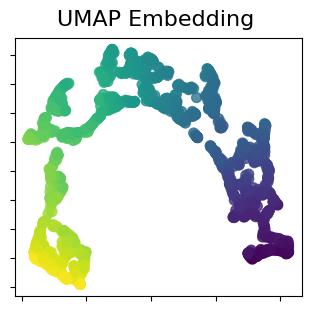

In [ ]:
plot_2d(S_umap, S_color, "UMAP Embedding")

**Ejercicio: Varia el número de vecinos para ver como cambia el resultado. Prueba {2,5,10,20,50,100,200}.**

### Datos reales

Vamos a aplicar ahora estos métodos a datos más reales.

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits(n_class=10)
X, y = digits.data, digits.target

print(X.shape, y.shape)

(1797, 64) (1797,)


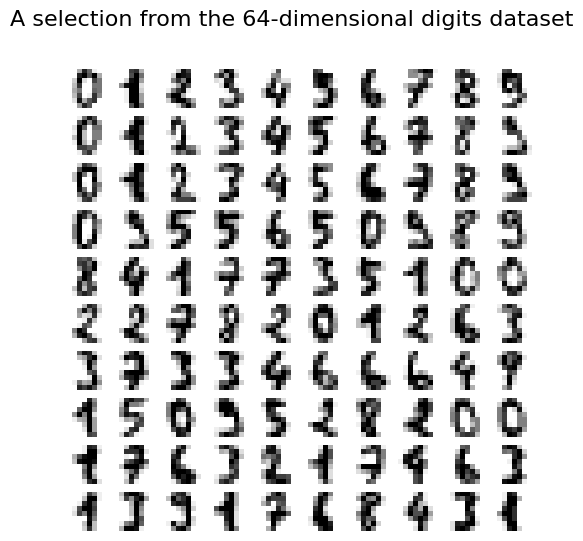

In [ ]:
fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(6, 6))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(X[idx].reshape((8, 8)), cmap=plt.cm.binary)
    ax.axis("off")
_ = fig.suptitle("A selection from the 64-dimensional digits dataset", fontsize=16)

Vamos a probar distintos métodos de los trabajados.

**Ejercicio: Prueba PCA, MDS, Isomap, t-SNE y UMAP para bajar los datos a dos dimensiones. Compara las representaciones.**

In [ ]:
import numpy as np
from matplotlib import offsetbox
from sklearn.preprocessing import MinMaxScaler

def plot_embedding(X, title):
    _, ax = plt.subplots()
    X = MinMaxScaler().fit_transform(X)

    for digit in digits.target_names:
        ax.scatter(
            *X[y == digit].T,
            marker=f"${digit}$",
            s=60,
            color=plt.cm.Dark2(digit),
            alpha=0.425,
            zorder=2,
        )
    shown_images = np.array([[1.0, 1.0]])  # just something big
    for i in range(X.shape[0]):
        # plot every digit on the embedding
        # show an annotation box for a group of digits
        dist = np.sum((X[i] - shown_images) ** 2, 1)
        if np.min(dist) < 4e-3:
            # don't show points that are too close
            continue
        shown_images = np.concatenate([shown_images, [X[i]]], axis=0)
        imagebox = offsetbox.AnnotationBbox(
            offsetbox.OffsetImage(digits.images[i], cmap=plt.cm.gray_r), X[i]
        )
        imagebox.set(zorder=1)
        ax.add_artist(imagebox)

    ax.set_title(title)
    ax.axis("off")

**Ejercicio: Usa la función previa para visualizar los resultados.**